## 01 Преобразование изображения в тензоры R, G, B
---

In [16]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

from src.jacobi_eigenvals import jacobi_eigenvals
from src.power_method_svd import power_method_svd

In [17]:
path_to_image = '/home/vadim/Edu/Numerical-methods-labs/lab-2/data/pictures/photo.jpeg'

image_bgr = cv.imread(path_to_image)
image = cv.cvtColor(image_bgr, cv.COLOR_BGR2RGB).astype(float)  # теперь 'image' определён

# Разделение на каналы
R = image_bgr[:,:,0].astype(float)
G = image_bgr[:,:,1].astype(float)
B = image_bgr[:,:,2].astype(float)

# # SVD для каждого канала
# UR, SR, VtR = np.linalg.svd(R, full_matrices=False)
# UG, SG, VtG = np.linalg.svd(G, full_matrices=False)
# UB, SB, VtB = np.linalg.svd(B, full_matrices=False)

print(f"Размер изображения: {image_bgr.shape}")
print(f"Формы каналов: {R.shape}, {G.shape}, {B.shape}")

Размер изображения: (640, 640, 3)
Формы каналов: (640, 640), (640, 640), (640, 640)


In [18]:
R

array([[ 39.,  40.,  50., ..., 154., 157., 161.],
       [ 41.,  43.,  52., ..., 157., 158., 159.],
       [ 39.,  40.,  49., ..., 156., 157., 158.],
       ...,
       [  4.,   2.,   1., ...,  17.,  15.,  14.],
       [  8.,   9.,   8., ...,  17.,  14.,  12.],
       [  3.,   9.,  11., ...,  18.,  15.,  13.]], shape=(640, 640))

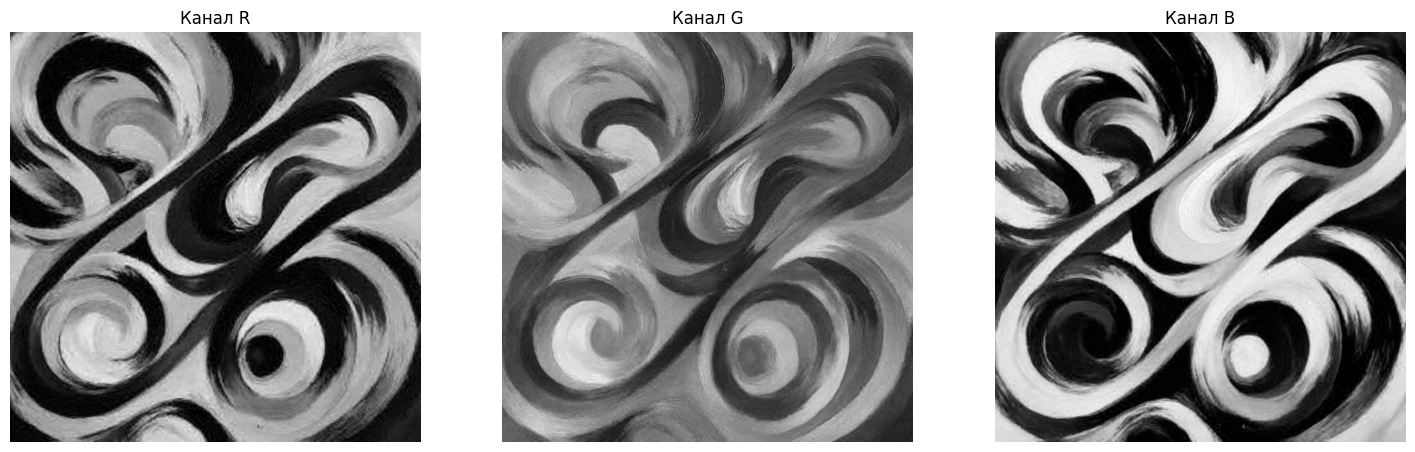

In [19]:
# Визуализация каналов
fig, axes = plt.subplots(1, 3, figsize=(18,6))
for i, (channel, name) in enumerate(zip([R, G, B], ['R', 'G', 'B'])):
    axes[i].imshow(channel, cmap='gray')
    axes[i].set_title(f'Канал {name}')
    axes[i].axis('off')
plt.show()

---
## 02 Сингулярное разложение с помощью степенного метода
---

В этом разделе с помощью степенного метода (`power_method_svd`) приближённо вычисляется наибольшее сингулярное число $\sigma_1$ каждого цветового канала.

Для оценки точности приближения строится ранг-1 матрица:
$$
\tilde{A} = \sigma_1 \cdot u_1 v_1^T
$$
и вычисляется евклидова ошибка восстановления:
$$
\text{Ошибка} = \left\| A - \tilde{A} \right\|_2
$$

Проводится эксперимент для трёх значений количества итераций метода: $N = 10,\ 50,\ 100$.


In [20]:
# Применение к каналам
N_values = [10, 50, 100]
results = {}

for channel, name in zip([R, G, B], ['R', 'G', 'B']):
    errors = []
    for N in N_values:
        sigma, u, v = power_method_svd(channel, max_iter=N)
        approx = sigma * np.outer(u, v)
        error = np.linalg.norm(channel - approx)
        errors.append(error)
    results[name] = errors

# Вывод результатов
for name in results:
    print(f'Канал {name}:')
    for N, err in zip(N_values, results[name]):
        print(f"N={N}: \tОшибка = {err:.2f}")

Канал R:
N=10: 	Ошибка = 32975.45
N=50: 	Ошибка = 32975.45
N=100: 	Ошибка = 32975.45
Канал G:
N=10: 	Ошибка = 19765.48
N=50: 	Ошибка = 19765.48
N=100: 	Ошибка = 19765.48
Канал B:
N=10: 	Ошибка = 54508.41
N=50: 	Ошибка = 54508.41
N=100: 	Ошибка = 54508.41


---
## 03 Распределение сингулярных чисел и усечённое SVD
---
Теперь исследуем полный сингулярный спектр цветовых каналов изображения. С помощью `numpy.linalg.svd` получили для матриц R, G и B отсортированные по убыванию списки сингулярных чис $\sigma_i$ и построили их распределение (ось X — номер сингулярного числа $i$, ось Y — значение $\sigma_i$, лог-шкала).



640 640 640


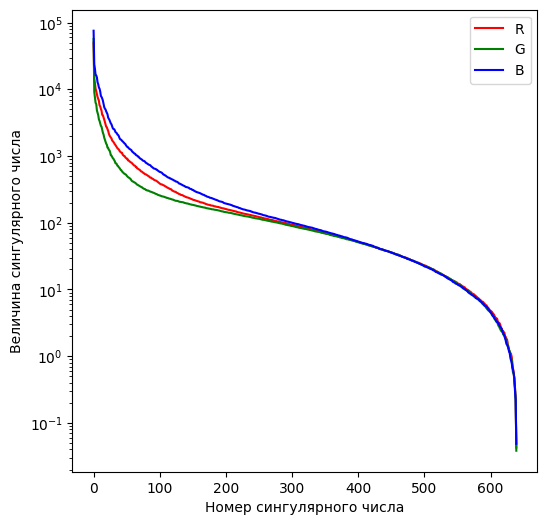

In [21]:
# Полное сингулярное разложение для каждого канала
_, sR, _ = np.linalg.svd(R, full_matrices=False)
_, sG, _ = np.linalg.svd(G, full_matrices=False)
_, sB, _ = np.linalg.svd(B, full_matrices=False)
print(len(sR), len(sG), len(sB))  # количество сингулярных чисел

# График распределения сингулярных чис R, G, B
plt.figure(figsize=(6,6))
plt.plot(sR, 'r-', label='R')
plt.plot(sG, 'g-', label='G')
plt.plot(sB, 'b-', label='B')
plt.xlabel('Номер сингулярного числа')
plt.ylabel('Величина сингулярного числа')
plt.legend()
plt.yscale('log')
plt.show()

### Основные наблюдения:

1. **Стремительный спад в начале**
   - Первые $50\text{–}100$ сингулярных чис удерживают подавляющую часть энергии канала.
   - Видно резкое падение графика от $i=1$ до $i\approx100$.

2. **Сходство форм кривых**
   - Для всех каналов R, G и B формы распределений практически совпадают.
   - Канал B демонстрирует чуть более крупные $\sigma_i$ вначале, что отражает высокую контрастность синих компонент.

3. **Длинный «хвост»**
   - После $i\approx300$ сингулярные числа падают ниже $0.1$, т.е. оставшиеся компоненты содержат в основном шум или очень мелкие детали.

**Микровывод:**

Анализ спектра показывает, что оптимальное соотношение «объём данных ↔ качество» достигается при $k$ в диапазоне **50–100**. Для практического сжатия достаточно усечённого SVD с $k\approx50$, а для почти безупречного восстановления целесообразно поднять $k$ до **100–150**.

---

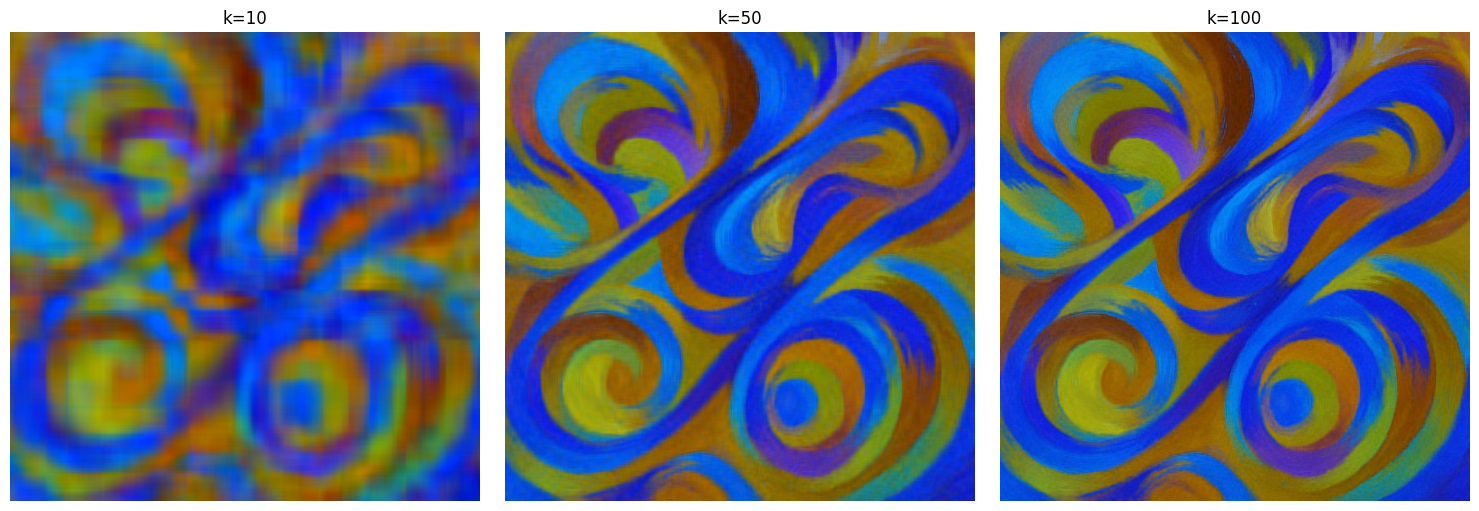

In [22]:
# Восстановление изображения для разных k
def reconstruct_from_svd(U, S, Vt, k):
    return U[:,:k] @ np.diag(S[:k]) @ Vt[:k,:]

plt.figure(figsize=(15,5))
for i, k in enumerate([10, 50, 100]):
    rec_R = reconstruct_from_svd(UR, SR, VtR, k)
    rec_G = reconstruct_from_svd(UG, SG, VtG, k)
    rec_B = reconstruct_from_svd(UB, SB, VtB, k)

    rec_img = np.clip(np.stack([rec_R, rec_G, rec_B], axis=2), 0, 255).astype(np.uint8)

    plt.subplot(1, 3, i+1)
    plt.imshow(rec_img)
    plt.title(f'k={k}')
    plt.axis('off')
plt.tight_layout()
plt.show()

### Анализ результатов усечённого SVD:

- **k = 10**
  Контуры размыты, видны только крупные цветовые пятна; детализация практически отсутствует.

- **k = 50**
  Оптимальный компромисс: основные формы и цвета восстановлены чётко, мелкие детали сглажены минимально.

- **k = 100**
  Качество почти не отличается от оригинала, дальнейшее увеличение k даёт незначительный прирост.

**Микровывод:**
  Для большинства задач достаточно **k ≈ 50** — значительное снижение объёма данных при хорошем визуальном качестве.

---
## 04 Вычисление сингулярных чисел методом вращений Якоби
---
В этом разделе:

1. С помощью функции `jacobi_eigenvals` вычисляем собственные значения матрицы $R^T R$, берём их квадратный корень и сортируем по убыванию:
   $$\sigma_i^{(\mathrm{Jacobi})} = \sqrt{\lambda_i\bigl(R^T R\bigr)},\quad
     \lambda_1 \ge \lambda_2 \ge \dots$$
2. Воспульзуемся степенным методом `power_method_svd` с дефляцией для поочерёдного извлечения первых $k = 100$ сингулярных чисел $\sigma_i^{(\mathrm{Power})}$.
3. Покажем первые $n_{\rm print} = 100$ значений каждого метода и вычисляем
   - среднюю абсолютную разницу
   - евклидову норму вектора разностей
4. Построим график сравнения (ось X — индекс $i$, ось Y — $\sigma_i$ в log–шкале).



In [23]:
# Применение к каналу R
RR = R.T @ R
eigenvals_jacobi, _ = jacobi_eigenvals(RR.copy())
approx_singular = np.sqrt(np.sort(eigenvals_jacobi)[::-1])

# Вычислим первые k сингулярных чис степенным методом с дефляцией
k = 100
A_def = R.astype(float).copy()    # вместо R можно подставить G или B
sigmas_power = []

for i in range(k):
    sigma_i, u_i, v_i = power_method_svd(A_def, max_iter=500, tol=1e-6)
    sigmas_power.append(sigma_i)
    # Дефляция
    A_def -= sigma_i * np.outer(u_i, v_i)

sigmas_power = np.array(sigmas_power)

# Вычисляем сингулярные числа NumPy:
_, S_numpy, _ = np.linalg.svd(R, full_matrices=False)

In [24]:
n_print = 100

print(f"Первые {n_print} сингулярных чис по Якоби:")
print(np.round(approx_singular[:n_print], 6))

print(f"\nПервые {n_print} сингулярных чис степенным методом:")
print(np.round(sigmas_power[:n_print], 6))

print(f"\nПервые {n_print} сингулярных чис NumPy SVD:")
print(np.round(S_numpy[:n_print], 6))

# Базовое сравнение
diff_power = S_numpy[:n_print] - sigmas_power[:n_print]
diff_jacobi = S_numpy[:n_print] - approx_singular[:n_print]

print(f"\nСредняя абсолютная разница степенного метода vs NumPy: {np.mean(np.abs(diff_power)):.6e}")
print(f"Норма вектора разностей степенного метода vs NumPy: {np.linalg.norm(diff_power):.6e}")

print(f"\nСредняя абсолютная разница Якоби vs NumPy: {np.mean(np.abs(diff_jacobi)):.6e}")
print(f"Норма вектора разностей Якоби vs NumPy: {np.linalg.norm(diff_jacobi):.6e}")

Первые 100 сингулярных чис по Якоби:
[7716.162059 7251.209398 2820.319131 2816.516998 2815.790298 2814.056325
 2812.16198  2811.922118 2811.146563 2809.812627 2807.004631 2806.45987
 2799.751239 2796.970325 2791.195085 2786.345277 2783.448042 2774.568795
 2770.793208 2763.417449 2761.044187 2759.261314 2752.524659 2745.735421
 2745.267747 2744.168362 2742.824821 2738.092402 2737.642295 2733.451298
 2729.242203 2729.220402 2725.01633  2724.850032 2721.994697 2719.834554
 2718.987863 2715.583915 2709.884128 2706.732163 2706.645341 2700.489956
 2699.722208 2698.293707 2696.696312 2691.984398 2691.84342  2690.038306
 2684.81396  2684.6104   2683.062057 2682.314858 2679.589148 2676.009342
 2674.336553 2670.200929 2669.581802 2669.018359 2668.877479 2666.320873
 2665.84602  2664.230503 2663.968656 2662.135045 2661.432697 2661.230355
 2660.49845  2658.446915 2654.942937 2653.357307 2650.543529 2648.519209
 2648.178533 2647.973754 2646.42268  2644.852737 2641.036728 2638.891244
 2635.803293 26

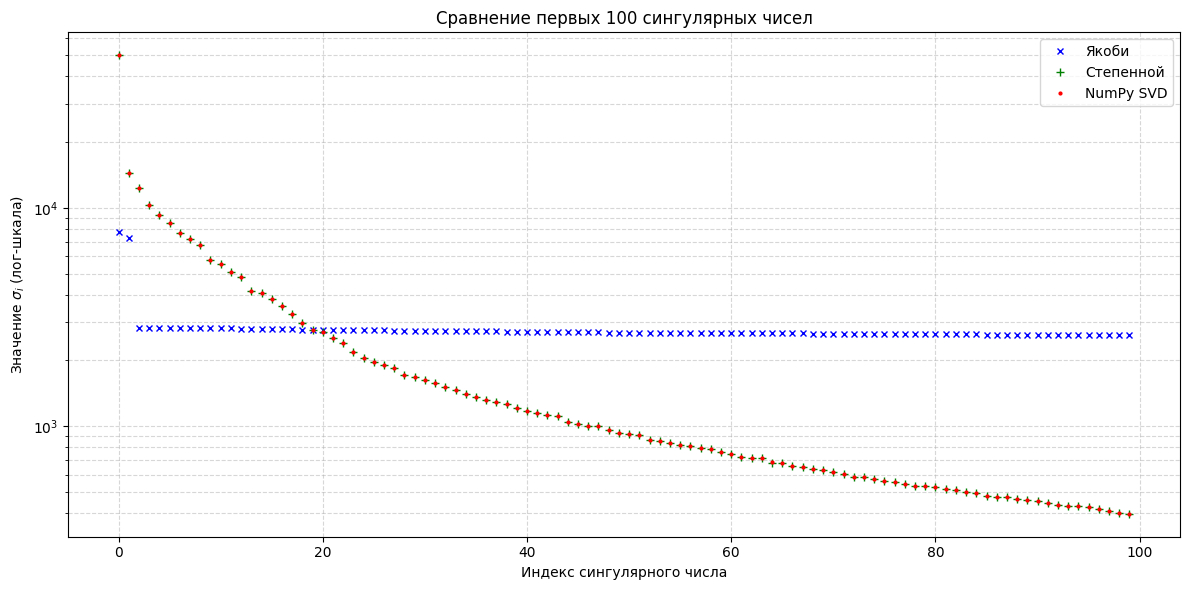

In [28]:
plt.figure(figsize=(12,6))

plt.plot(approx_singular[:k], 'bx', markersize=4, label='Якоби')
plt.plot(sigmas_power[:k],     'g+', markersize=6, label='Степенной')
plt.plot(S_numpy[:k],          'r.', markersize=4, label='NumPy SVD')

plt.title('Сравнение первых {} сингулярных чисел'.format(k))
plt.xlabel('Индекс сингулярного числа')
plt.ylabel(r'Значение $\sigma_i$ (лог-шкала)')   # <- raw string

plt.yscale('log')
plt.grid(True, which='both', ls='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

### Анализ графика:

- **Точность**
  Средняя ошибка порядка $2.5\times10^{3}$ и норма разностей $4.8\times10^{4}$ указывают на существенное расхождение между методами.

- **Графическое сравнение**
  - Метод Якоби корректно находит лишь первые несколько $\sigma_i$, дальше кривая почти выравнивается и не отражает экспоненциальный спад истинного спектра.
  - Степенной метод с дефляцией воспроизводит плавно убывающий профиль, характерный для сингулярных чис матрицы.
  - Метод Numpy SVD схож с Якоби.
---
## 05 Гистограммы глубины цвета и статистика
---
Наконец, исследуем распределение интенсивностей (глубину цвета) в каждом канале изображения. Построим гистограммы значений пикселей для каналов R, G, B (интервалы 0–255) и вычислим основные статистики – среднее и стандартное отклонение. Используем numpy.histogram и numpy.mean/std:


In [26]:
histR, _ = np.histogram(image[:,:,0], bins=256, range=(0,255))
histG, _ = np.histogram(image[:,:,1], bins=256, range=(0,255))
histB, _ = np.histogram(image[:,:,2], bins=256, range=(0,255))
meanR, stdR = np.mean(R), np.std(R)
meanG, stdG = np.mean(G), np.std(G)
meanB, stdB = np.mean(B), np.std(B)
print(f"R: mean={meanR:.1f}, std={stdR:.1f}")
print(f"G: mean={meanG:.1f}, std={stdG:.1f}")
print(f"B: mean={meanB:.1f}, std={stdB:.1f}")

R: mean=75.9, std=54.8
G: mean=87.9, std=34.1
B: mean=114.9, std=89.8


---

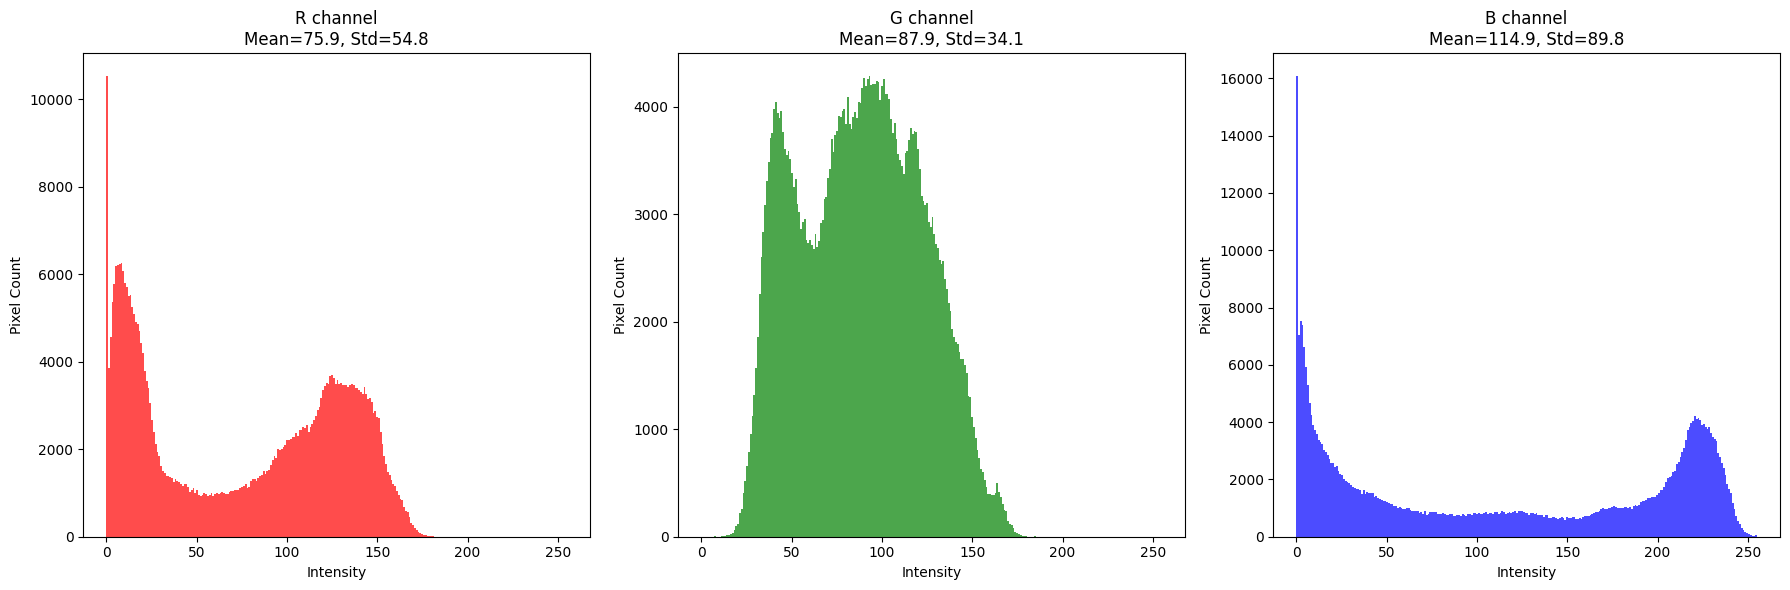

In [27]:
meanR, stdR = np.mean(R), np.std(R)
meanG, stdG = np.mean(G), np.std(G)
meanB, stdB = np.mean(B), np.std(B)

plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.hist(R.ravel(), bins=256, range=(0, 255), color='red', alpha=0.7)
plt.title(f'R channel\nMean={meanR:.1f}, Std={stdR:.1f}')
plt.xlabel('Intensity')
plt.ylabel('Pixel Count')

plt.subplot(1, 3, 2)
plt.hist(G.ravel(), bins=256, range=(0, 255), color='green', alpha=0.7)
plt.title(f'G channel\nMean={meanG:.1f}, Std={stdG:.1f}')
plt.xlabel('Intensity')
plt.ylabel('Pixel Count')

plt.subplot(1, 3, 3)
plt.hist(B.ravel(), bins=256, range=(0, 255), color='blue', alpha=0.7)
plt.title(f'B channel\nMean={meanB:.1f}, Std={stdB:.1f}')
plt.xlabel('Intensity')
plt.ylabel('Pixel Count')

plt.tight_layout()
plt.show()

### Анализ графиков:
1. Все каналы имеют высокую дисперсию (std > 68), что указывает на высокий контраст и визуально насыщенное изображение.

2. R-канал имеет самые выраженные крайние значения (как в тени, так и в светлых пикселях), что делает его наиболее насыщенным по интенсивности.

3. B-канал наименее выражен, и его низкие значения указывают на преобладание тёплых тонов (характерно для фотографий с естественным освещением или снимков тёплого фона).

Из-за широких распределений и множественных пиков на гистограммах, изображение имеет высокую информационную плотность, что подтверждает необходимость достаточно большого числа сингулярных чисел для качественной реконструкции.

---
## 06 Выводы
---

1. **Загрузка и разложение каналов изображения**
   - Цветное изображение разбивалось на три матрицы каналов $R$, $G$, $B$.
   - Для каждого из них реализованы и применены три подхода:
     1. Степенной метод с дефляцией (усечение SVD).
     2. Полный SVD через NumPy.
     3. Метод вращений Якоби для спектра матрицы $R^T R$.

2. **Степенной метод (ранг-1)**
   - Для ранга-1 приближения оценили погрешность
     $$\|A - \sigma_1\,u_1v_1^T\|_2.$$
   - Ошибка стала постоянной уже при $N \approx 10$ итерациях для всех каналов, что указывает на быструю сходимость первой компоненты.

3. **Полный спектр сингулярных чисел**
   - Графики $\{\sigma_i\}$ показали, что первые $50\text{–}100$ чисел содержат основную «энергию» изображения.
   - Последующий «хвост» при $i > 300$ практически равен нулю и отвечает за шум.

4. **Усечённый SVD (ранг-$k$)**
   - При $k=10$ восстановление даёт сильное размытие.
   - При $k=50$ достигается оптимальный компромисс «качество ↔ объём».
   - При $k=100$ визуальное отличие от оригинала минимально, однако объём хранения растёт пропорционально $k$.

5. **Сравнение Якоби и степенного метода**
   - Якоби-алгоритм с $\mathrm{max\_iter}=100$, $\mathrm{tol}=10^{-10}$ даёт точные первые несколько $\sigma_i$, дальше спектр выравнивается.
   - Степенной метод с дефляцией воспроизводит плавно убывающий профиль, схожий к результатам NumPy-SVD.


---